# Importing Libraries

In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score, classification_report

# Reading the Dataset

In [2]:
file_path = "heart.csv"  # Change the path if it is different
df = pd.read_csv(file_path)

df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


# Data Analysis

## Checking the Dataset

In [3]:
print(f"The data types for each column:\n{df.dtypes}")
print(f"\nThe shape of the dataset is: {df.shape}")
print(f"\nThe number of missing values in each column:\n{df.isnull().sum()}")

The data types for each column:
Age                 int64
Sex                object
ChestPainType      object
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG         object
MaxHR               int64
ExerciseAngina     object
Oldpeak           float64
ST_Slope           object
HeartDisease        int64
dtype: object

The shape of the dataset is: (918, 12)

The number of missing values in each column:
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64


## Distribution of the Target Labels

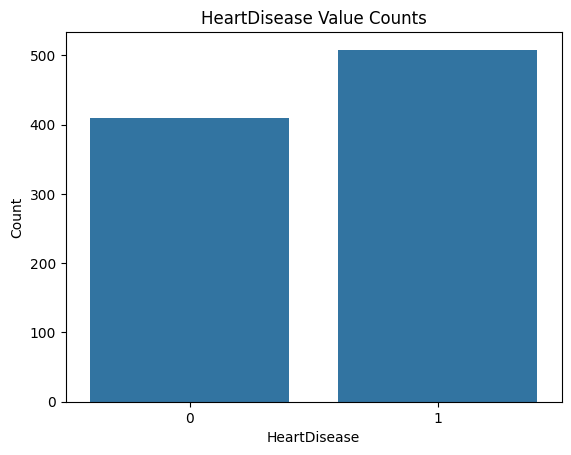

In [4]:
# Count plot of HeartDisease values
sns.countplot(x='HeartDisease', data=df)

plt.title('HeartDisease Value Counts')
plt.xlabel('HeartDisease')
plt.ylabel('Count')
plt.show()

# Encoding Categorical Features

In [5]:
categorical_cols = ["Sex", "ChestPainType", "RestingECG", "ExerciseAngina", "ST_Slope"]
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print(f"Shape after encoding: {df_encoded.shape}")
print(f"Current columns:\n{df_encoded.columns.tolist()}")

Shape after encoding: (918, 16)
Current columns:
['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak', 'HeartDisease', 'Sex_M', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_Normal', 'RestingECG_ST', 'ExerciseAngina_Y', 'ST_Slope_Flat', 'ST_Slope_Up']


# Train-Test Splitting

In [6]:
feature_cols = [c for c in df_encoded.columns if c != 'HeartDisease']

X = df_encoded[feature_cols].astype(float)
y = df_encoded['HeartDisease'].astype(float)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set shape: {X_train.shape} | Testing set shape: {X_test.shape}")

Training set shape: (734, 15) | Testing set shape: (184, 15)


# Scaling the Columns

In [7]:
scaler = StandardScaler()

X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

y_train = y_train.to_numpy()
y_test = y_test.to_numpy()

# Tasks Starts Here

## Weight Initialization

In [8]:
def init_weights(num_features, num_hidden_layer, random_seed=42):
    """
    Using Xavier initialization
    """

    random.seed(random_seed)

    W1 = [[random.gauss(0, (2.0 / num_features) ** 0.5) for _ in range(num_features)] for _ in range(num_hidden_layer)]
    b1 = [0.0] * num_hidden_layer

    W2 = [random.gauss(0, (2.0 / num_hidden_layer) ** 0.5) for _ in range(num_hidden_layer)]
    b2 = 0.0

    return W1, b1, W2, b2

## Implement the ReLU Function

In [9]:
def relu(z):
    # ------------ YOUR CODE STARTS HERE ------------
    return max(0.0, z)
    # ------------ YOUR CODE ENDS HERE --------------

## Implement the Sigmoid Function

In [10]:
def sigmoid(z):
    # ------------ YOUR CODE STARTS HERE ------------
    return 1 / (1 + math.exp(-z))
    # ------------ YOUR CODE ENDS HERE --------------

## Implement the Forward Propagation

In [11]:
def forward_prop_single(x, W1, b1, W2, b2):
    """
    Forward pass for a single sample from the dataset
    """

    num_hidden_layer = len(W1)
    num_features = len(x)

    # --- Layer 1: z1 = (W1^T)x + b1 ---
    z1 = []
    for j in range(num_hidden_layer):
        z = 0.0
        for k in range(num_features):
        # ------------ YOUR CODE STARTS HERE ------------
            z += W1[j][k] * x[k]
        z += b1[j]

        z1.append(z)
        # ------------ YOUR CODE ENDS HERE --------------


    # --- Apply ReLU ---
    a1 = [relu(z) for z in z1]


    # --- Layer 2: z2 = (W2^T)a1 + b2 ---
    z2 = 0.0
    for j in range(num_hidden_layer):
    # ------------ YOUR CODE STARTS HERE ------------
        z2 += W2[j] * a1[j]
    # ------------ YOUR CODE ENDS HERE --------------


    # --- Apply Sigmoid ---
    y_hat = sigmoid(z2)

    return z1, a1, z2, y_hat



def forward_prop(X, W1, b1, W2, b2):
    """
    Returns the predicted probabilities for all the samples in the dataset
    """
    return [forward_prop_single(X[i], W1, b1, W2, b2)[-1] for i in range(len(X))]

## Implementing the Binary Cross-Entropy Loss

In [12]:
def bce_loss(X, y, W1, b1, W2, b2):
    m = len(y)
    total_loss = 0.0

    for i in range(m):
        _, _, _, y_hat = forward_prop_single(X[i], W1, b1, W2, b2)

        # Numerical clipping to avoid log(0)
        p = max(1e-15, min(1 - 1e-15, y_hat))

        # Calculate BCE loss for sample i and accumulate it in total_loss
        # ------------ YOUR CODE STARTS HERE ------------
        total_loss += -(y[i] * math.log(p) + (1 - y[i]) * math.log(1 - p))
        # ------------ YOUR CODE ENDS HERE --------------

    return total_loss / m

## Implement Backpropagation

In [13]:
def backprop(X, y, W1, b1, W2, b2):
    m = len(y)
    num_hidden_layer = len(W1)
    num_features = len(X[0])

    # Initialize gradients
    dW1 = [[0.0] * num_features for _ in range(num_hidden_layer)]
    db1 = [0.0] * num_hidden_layer
    dW2 = [0.0] * num_hidden_layer
    db2 = 0.0

    for i in range(m):
        z1, a1, z2, y_hat = forward_prop_single(X[i], W1, b1, W2, b2)

        # Calculate dW2 and db2
        # ------------ YOUR CODE STARTS HERE ------------
        dz2 = y_hat - y[i]

        for j in range(num_hidden_layer):
            dW2[j] += dz2 * a1[j]
        db2 += dz2
        # ------------ YOUR CODE ENDS HERE --------------

        # Calculate dW1 and db1
        # ------------ YOUR CODE STARTS HERE ------------
        for j in range(num_hidden_layer):
            da1 = dz2 * W2[j]

            #ReLu derivative
            if z1[j] > 0:
                dz1 = da1
            else:
                dz1 = 0

            #Hidden layer bias
            db1[j] += dz1

            for k in range(num_features):
                dW1[j][k] += dz1 * X[i][k]


        # ------------ YOUR CODE ENDS HERE --------------

    # Average over all samples
    for j in range(num_hidden_layer):
        for k in range(num_features):
            dW1[j][k] /= m
        db1[j] /= m
        dW2[j] /= m
    db2 /= m

    return dW1, db1, dW2, db2

Visualize the arrays.

Suppose your dataset has:

* **3 input features**
* **2 hidden neurons**
* **4 training samples**

Then

```python
X =
[
 [1, 2, 3],    # Sample 0
 [4, 5, 6],    # Sample 1
 [7, 8, 9],    # Sample 2
 [2, 1, 0]     # Sample 3
]
```

**W1**

Since there are 2 hidden neurons and 3 input features,

```
W1 = (2 × 3)

          x1   x2   x3
Neuron1 [0.1 0.2 0.3]
Neuron2 [0.4 0.5 0.6]
```



## Weight Update

In [14]:
def weight_update(W1, b1, W2, b2, dW1, db1, dW2, db2, learning_rate=0.05):
    num_hidden_layer = len(W1)
    num_features = len(W1[0])

    for j in range(num_hidden_layer):
        for k in range(num_features):
            W1[j][k] -= learning_rate * dW1[j][k]
        b1[j] -= learning_rate * db1[j]
        W2[j] -= learning_rate * dW2[j]
    b2 -= learning_rate * db2

    return W1, b1, W2, b2

## Calculate Accuracy

In [15]:
def predict_class(X, W1, b1, W2, b2, threshold=0.5):
    return [1 if p >= threshold else 0 for p in forward_prop(X, W1, b1, W2, b2)]

def calculate_accuracy(X, y, W1, b1, W2, b2):
    y_pred = predict_class(X, W1, b1, W2, b2)

    return sum(1 for i in range(len(y)) if y_pred[i] == int(y[i])) / len(y)

## Training Loop

In [24]:
def train_nn(X_train, y_train, X_test, y_test, num_hidden_layer=16, learning_rate=0.05, epochs=300, random_seed=42):
    """
    Train a two-layer neural network with gradient descent.

    Returns
    -------
    params       : final (W1, b1, W2, b2)
    train_losses, test_losses   : BCE per epoch
    train_accs,   test_accs     : accuracy per epoch
    """
    num_features = len(X_train[0])
    W1, b1, W2, b2 = init_weights(num_features, num_hidden_layer, random_seed=42)

    train_losses, test_losses = [], []
    train_accs, test_accs = [], []

    for epoch in range(epochs):
        # Forward + backward
        dW1, db1, dW2, db2 = backprop(X_train, y_train, W1, b1, W2, b2)
        # current_lr = learning_rate * (0.1 ** (epoch // 100))

        # W1, b1, W2, b2 = weight_update(
        #   W1,b1,W2,b2,
        #   dW1,db1,dW2,db2,
        #   current_lr
        # )

        max_lr = 0.1
        min_lr = 0.001

        half = epochs // 2

        if epoch <= half:
          current_lr = min_lr + (max_lr - min_lr) * (epoch / half)
        else:
          current_lr = max_lr - (max_lr - min_lr) * ((epoch-half)/half)

        W1,b1,W2,b2 = weight_update(
          W1,b1,W2,b2,
          dW1,db1,dW2,db2,
          current_lr
        )

        # Record metrics
        tr_loss = bce_loss(X_train, y_train, W1, b1, W2, b2)
        te_loss = bce_loss(X_test,  y_test,  W1, b1, W2, b2)
        tr_acc  = calculate_accuracy(X_train, y_train, W1, b1, W2, b2)
        te_acc  = calculate_accuracy(X_test,  y_test,  W1, b1, W2, b2)

        train_losses.append(tr_loss)
        test_losses.append(te_loss)
        train_accs.append(tr_acc)
        test_accs.append(te_acc)

        if (epoch + 1) % 50 == 0:
            print(f"Epoch {epoch+1:4d} | "
                  f"Train Loss: {tr_loss:.4f}  Acc: {tr_acc:.4f} | "
                  f"Test Loss: {te_loss:.4f}  Acc: {te_acc:.4f}")

    return (W1, b1, W2, b2), train_losses, test_losses, train_accs, test_accs

In [27]:
def train_nn_minibatch(
    X_train,
    y_train,
    X_test,
    y_test,
    num_hidden_layer=16,
    learning_rate=0.05,
    epochs=300,
    batch_size=32,
    random_seed=42
):
    """
    Train a two-layer neural network using Mini-Batch Gradient Descent.
    """

    np.random.seed(random_seed)

    num_features = len(X_train[0])

    W1, b1, W2, b2 = init_weights(
        num_features,
        num_hidden_layer,
        random_seed
    )

    train_losses = []
    test_losses = []
    train_accs = []
    test_accs = []

    m = len(X_train)

    for epoch in range(epochs):

        # Shuffle the training data every epoch
        indices = np.random.permutation(m)
        X_shuffled = X_train[indices]
        y_shuffled = y_train[indices]

        # Process one mini-batch at a time
        for start in range(0, m, batch_size):

            end = start + batch_size

            X_batch = X_shuffled[start:end]
            y_batch = y_shuffled[start:end]

            # Compute gradients on the mini-batch
            dW1, db1, dW2, db2 = backprop(
                X_batch,
                y_batch,
                W1,
                b1,
                W2,
                b2
            )

            # Update weights
            W1, b1, W2, b2 = weight_update(
                W1,
                b1,
                W2,
                b2,
                dW1,
                db1,
                dW2,
                db2,
                learning_rate
            )

        # Evaluate after each epoch
        tr_loss = bce_loss(X_train, y_train, W1, b1, W2, b2)
        te_loss = bce_loss(X_test, y_test, W1, b1, W2, b2)

        tr_acc = calculate_accuracy(X_train, y_train, W1, b1, W2, b2)
        te_acc = calculate_accuracy(X_test, y_test, W1, b1, W2, b2)

        train_losses.append(tr_loss)
        test_losses.append(te_loss)

        train_accs.append(tr_acc)
        test_accs.append(te_acc)

        if (epoch + 1) % 50 == 0:
            print(f"Epoch {epoch+1:4d} | "
                  f"Train Loss: {tr_loss:.4f}  Acc: {tr_acc:.4f} | "
                  f"Test Loss: {te_loss:.4f}  Acc: {te_acc:.4f}")

    return (
        (W1, b1, W2, b2),
        train_losses,
        test_losses,
        train_accs,
        test_accs
    )

# Complete the Tasks

## Task 1

In [17]:
params, train_losses, test_losses, train_accs, test_accs = train_nn(
    X_train_s,
    y_train,
    X_test_s,
    y_test,
    num_hidden_layer=16,
    learning_rate=0.05,
    epochs=300
)

Epoch   50 | Train Loss: 0.4844  Acc: 0.7807 | Test Loss: 0.5177  Acc: 0.7717
Epoch  100 | Train Loss: 0.3948  Acc: 0.8324 | Test Loss: 0.4187  Acc: 0.8315
Epoch  150 | Train Loss: 0.3632  Acc: 0.8488 | Test Loss: 0.3761  Acc: 0.8424
Epoch  200 | Train Loss: 0.3463  Acc: 0.8556 | Test Loss: 0.3524  Acc: 0.8750
Epoch  250 | Train Loss: 0.3362  Acc: 0.8678 | Test Loss: 0.3381  Acc: 0.8804
Epoch  300 | Train Loss: 0.3292  Acc: 0.8706 | Test Loss: 0.3293  Acc: 0.8804


## Task 2

Part A

Epoch   50 | Train Loss: 0.4992  Acc: 0.6907 | Test Loss: 0.5479  Acc: 0.6848
Epoch  100 | Train Loss: 0.4585  Acc: 0.7125 | Test Loss: 0.4890  Acc: 0.7065
Epoch  150 | Train Loss: 0.4401  Acc: 0.7725 | Test Loss: 0.4653  Acc: 0.7935
Epoch  200 | Train Loss: 0.4217  Acc: 0.8120 | Test Loss: 0.4438  Acc: 0.8315
Epoch  250 | Train Loss: 0.3929  Acc: 0.8447 | Test Loss: 0.4162  Acc: 0.8533
Epoch  300 | Train Loss: 0.3643  Acc: 0.8460 | Test Loss: 0.3902  Acc: 0.8750
Epoch   50 | Train Loss: 0.5116  Acc: 0.7221 | Test Loss: 0.4734  Acc: 0.7880
Epoch  100 | Train Loss: 0.4250  Acc: 0.8406 | Test Loss: 0.4011  Acc: 0.8587
Epoch  150 | Train Loss: 0.3699  Acc: 0.8583 | Test Loss: 0.3553  Acc: 0.8696
Epoch  200 | Train Loss: 0.3477  Acc: 0.8542 | Test Loss: 0.3387  Acc: 0.8696
Epoch  250 | Train Loss: 0.3361  Acc: 0.8597 | Test Loss: 0.3304  Acc: 0.8696
Epoch  300 | Train Loss: 0.3283  Acc: 0.8624 | Test Loss: 0.3251  Acc: 0.8750
Epoch   50 | Train Loss: 0.4844  Acc: 0.7807 | Test Loss: 0.5177

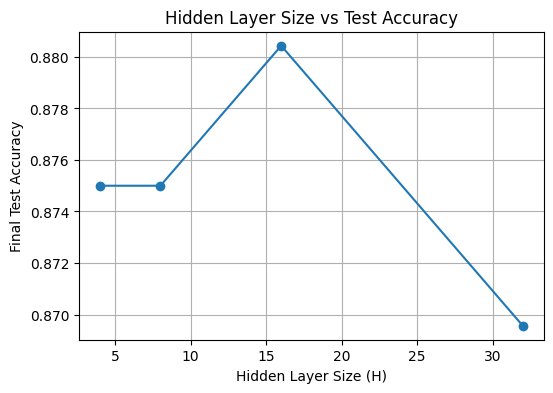

[0.875, 0.875, 0.8804347826086957, 0.8695652173913043]


In [18]:
hidden_sizes = [4, 8, 16, 32]
test_accuracies = []

for H in hidden_sizes:
    params, train_losses, test_losses, train_accs, test_accs = train_nn(
        X_train_s,
        y_train,
        X_test_s,
        y_test,
        num_hidden_layer=H,
        learning_rate=0.05,
        epochs=300
    )

    test_accuracies.append(test_accs[-1])

plt.figure(figsize=(6,4))
plt.plot(hidden_sizes, test_accuracies, marker='o')
plt.xlabel("Hidden Layer Size (H)")
plt.ylabel("Final Test Accuracy")
plt.title("Hidden Layer Size vs Test Accuracy")
plt.grid(True)
plt.show()

print(test_accuracies)

Answer
---

> The hidden layer size determines the learning capacity of the neural network. A small hidden layer may not be able to learn complex patterns in the data, leading to underfitting. Increasing the hidden layer size generally improves the model's ability to learn, but after a certain point it may cause overfitting and poorer generalization. Therefore, a larger hidden layer does not always produce better test accuracy. As we can see

Part B

Epoch   50 | Train Loss: 1.4543  Acc: 0.4155 | Test Loss: 1.4425  Acc: 0.4130
Epoch  100 | Train Loss: 1.3764  Acc: 0.4169 | Test Loss: 1.3664  Acc: 0.4185
Epoch  150 | Train Loss: 1.3055  Acc: 0.4360 | Test Loss: 1.2972  Acc: 0.4293
Epoch  200 | Train Loss: 1.2408  Acc: 0.4578 | Test Loss: 1.2345  Acc: 0.4402
Epoch  250 | Train Loss: 1.1816  Acc: 0.4659 | Test Loss: 1.1775  Acc: 0.4402
Epoch  300 | Train Loss: 1.1276  Acc: 0.4850 | Test Loss: 1.1256  Acc: 0.4402
Epoch   50 | Train Loss: 0.9530  Acc: 0.5395 | Test Loss: 0.9592  Acc: 0.4837
Epoch  100 | Train Loss: 0.7114  Acc: 0.6308 | Test Loss: 0.7324  Acc: 0.5924
Epoch  150 | Train Loss: 0.5946  Acc: 0.7125 | Test Loss: 0.6244  Acc: 0.7011
Epoch  200 | Train Loss: 0.5280  Acc: 0.7534 | Test Loss: 0.5611  Acc: 0.7554
Epoch  250 | Train Loss: 0.4854  Acc: 0.7779 | Test Loss: 0.5187  Acc: 0.7772
Epoch  300 | Train Loss: 0.4558  Acc: 0.7997 | Test Loss: 0.4881  Acc: 0.7772
Epoch   50 | Train Loss: 0.4844  Acc: 0.7807 | Test Loss: 0.5177

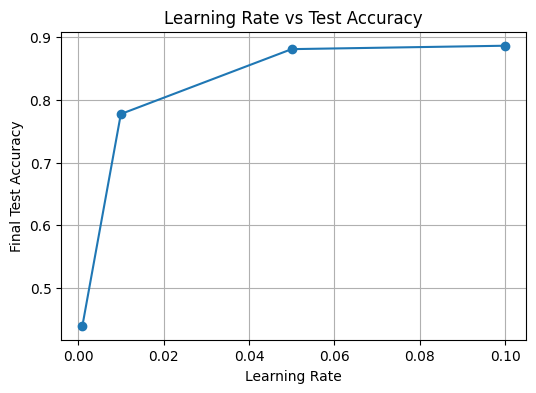

[0.44021739130434784, 0.7771739130434783, 0.8804347826086957, 0.8858695652173914]


In [19]:
learning_rates = [0.001, 0.01, 0.05, 0.1]
lr_test_acc = []

for lr in learning_rates:

    params, train_losses, test_losses, train_accs, test_accs = train_nn(
        X_train_s,
        y_train,
        X_test_s,
        y_test,
        num_hidden_layer=16,
        learning_rate=lr,
        epochs=300
    )

    lr_test_acc.append(test_accs[-1])

plt.figure(figsize=(6,4))
plt.plot(learning_rates, lr_test_acc, marker='o')
plt.xlabel("Learning Rate")
plt.ylabel("Final Test Accuracy")
plt.title("Learning Rate vs Test Accuracy")
plt.grid(True)
plt.show()

print(lr_test_acc)

## Task 3

Schedular A result



Epoch   50 | Train Loss: 0.4844  Acc: 0.7807 | Test Loss: 0.5177  Acc: 0.7717
Epoch  100 | Train Loss: 0.3948  Acc: 0.8324 | Test Loss: 0.4187  Acc: 0.8315
Epoch  150 | Train Loss: 0.3904  Acc: 0.8324 | Test Loss: 0.4132  Acc: 0.8370
Epoch  200 | Train Loss: 0.3863  Acc: 0.8338 | Test Loss: 0.4080  Acc: 0.8370
Epoch  250 | Train Loss: 0.3859  Acc: 0.8338 | Test Loss: 0.4075  Acc: 0.8370
Epoch  300 | Train Loss: 0.3856  Acc: 0.8338 | Test Loss: 0.4070  Acc: 0.8370


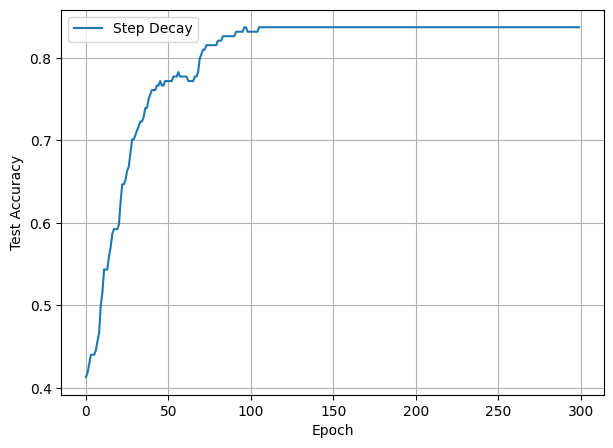

In [23]:
params1, train_losses1, test_losses1, train_accs1, test_accs1 = train_nn(
    X_train_s,
    y_train,
    X_test_s,
    y_test,
    num_hidden_layer=16,
    learning_rate=0.05,
    epochs=300
)
plt.figure(figsize=(7,5))

plt.plot(test_accs1,label="Step Decay")

plt.xlabel("Epoch")
plt.ylabel("Test Accuracy")
plt.legend()
plt.grid(True)
plt.show()

Schedular B result

Epoch   50 | Train Loss: 0.7600  Acc: 0.6131 | Test Loss: 0.7773  Acc: 0.5870
Epoch  100 | Train Loss: 0.4389  Acc: 0.8106 | Test Loss: 0.4700  Acc: 0.7772
Epoch  150 | Train Loss: 0.3628  Acc: 0.8488 | Test Loss: 0.3756  Acc: 0.8424
Epoch  200 | Train Loss: 0.3388  Acc: 0.8638 | Test Loss: 0.3417  Acc: 0.8750
Epoch  250 | Train Loss: 0.3310  Acc: 0.8706 | Test Loss: 0.3316  Acc: 0.8804
Epoch  300 | Train Loss: 0.3288  Acc: 0.8706 | Test Loss: 0.3290  Acc: 0.8804


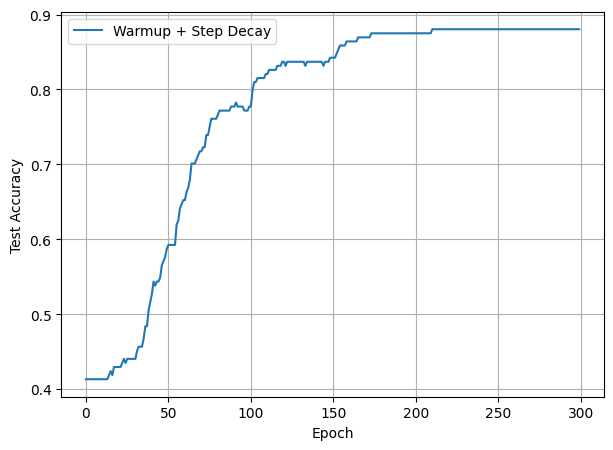

In [25]:
params1, train_losses1, test_losses1, train_accs1, test_accs1 = train_nn(
    X_train_s,
    y_train,
    X_test_s,
    y_test,
    num_hidden_layer=16,
    learning_rate=0.05,
    epochs=300
)
plt.figure(figsize=(7,5))

plt.plot(test_accs1,label="Warmup + Step Decay")



plt.xlabel("Epoch")
plt.ylabel("Test Accuracy")
plt.legend()
plt.grid(True)
plt.show()

**Comparison**
---
>1. Step Decay Scheduler
Observation
Accuracy increases rapidly during the first 50 epochs.
It reaches around 84% accuracy by approximately 100 epochs.
After that, the accuracy remains almost constant.
Reason

The learning rate starts relatively high (0.05), allowing the model to make large updates and learn quickly in the early stages. Every 100 epochs, the learning rate is reduced by a factor of 10, resulting in smaller updates that help stabilize training. However, the model converges to a local optimum around 84%, leaving little room for further improvement.

>2. Warmup + Step Decay Scheduler
Observation
Training is slower during the first 40–50 epochs.
Accuracy continues to improve steadily even after 100 epochs.
The model finally reaches approximately 88% test accuracy, outperforming the step decay scheduler.
Reason

The learning rate starts very small (0.001), preventing unstable weight updates during the early training stage. It gradually increases to a larger value, allowing the model to explore the parameter space more effectively. As the learning rate decreases again later in training, the model makes fine adjustments to the weights, resulting in better convergence and higher final accuracy.

#Task 4

In [26]:
from sklearn.neural_network import MLPClassifier

clf = MLPClassifier(
    hidden_layer_sizes=(16,),
    activation='relu',
    solver='sgd',
    learning_rate_init=0.05,
    max_iter=300,
    random_state=42
)

clf.fit(X_train_s, y_train)

pred = clf.predict(X_test_s)

print(classification_report(y_test, pred))

print("Test Accuracy:", accuracy_score(y_test, pred))

              precision    recall  f1-score   support

         0.0       0.85      0.82      0.83        82
         1.0       0.86      0.88      0.87       102

    accuracy                           0.85       184
   macro avg       0.85      0.85      0.85       184
weighted avg       0.85      0.85      0.85       184

Test Accuracy: 0.8532608695652174


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


**Comparison**
---
>The scikit-learn implementation generally achieves slightly better performance because it uses optimized numerical libraries, efficient matrix operations, improved weight initialization, adaptive optimization techniques, and more stable convergence. The custom implementation uses simple full-batch gradient descent and manual loops, making it slower and potentially less accurate.

Epoch   50 | Train Loss: 0.7600  Acc: 0.6131 | Test Loss: 0.7773  Acc: 0.5870
Epoch  100 | Train Loss: 0.4389  Acc: 0.8106 | Test Loss: 0.4700  Acc: 0.7772
Epoch  150 | Train Loss: 0.3628  Acc: 0.8488 | Test Loss: 0.3756  Acc: 0.8424
Epoch  200 | Train Loss: 0.3388  Acc: 0.8638 | Test Loss: 0.3417  Acc: 0.8750
Epoch  250 | Train Loss: 0.3310  Acc: 0.8706 | Test Loss: 0.3316  Acc: 0.8804
Epoch  300 | Train Loss: 0.3288  Acc: 0.8706 | Test Loss: 0.3290  Acc: 0.8804
Epoch   50 | Train Loss: 0.2840  Acc: 0.8856 | Test Loss: 0.3103  Acc: 0.8859
Epoch  100 | Train Loss: 0.2518  Acc: 0.8924 | Test Loss: 0.3226  Acc: 0.8859
Epoch  150 | Train Loss: 0.2297  Acc: 0.9101 | Test Loss: 0.3333  Acc: 0.8750
Epoch  200 | Train Loss: 0.2121  Acc: 0.9114 | Test Loss: 0.3453  Acc: 0.8750
Epoch  250 | Train Loss: 0.1948  Acc: 0.9210 | Test Loss: 0.3594  Acc: 0.8913
Epoch  300 | Train Loss: 0.1788  Acc: 0.9305 | Test Loss: 0.3794  Acc: 0.8859


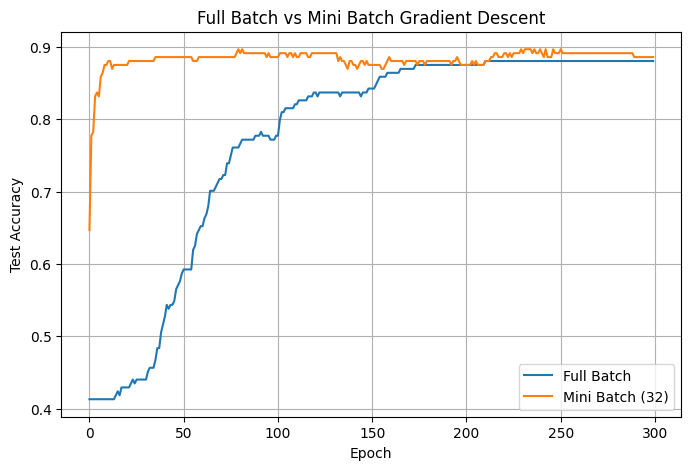

In [28]:
# Full Batch
params_fb, train_losses_fb, test_losses_fb, train_accs_fb, test_accs_fb = train_nn(
    X_train_s,
    y_train,
    X_test_s,
    y_test,
    num_hidden_layer=16,
    learning_rate=0.05,
    epochs=300
)

# Mini Batch
params_mb, train_losses_mb, test_losses_mb, train_accs_mb, test_accs_mb = train_nn_minibatch(
    X_train_s,
    y_train,
    X_test_s,
    y_test,
    num_hidden_layer=16,
    learning_rate=0.05,
    epochs=300,
    batch_size=32
)

plt.figure(figsize=(8,5))

plt.plot(test_accs_fb, label="Full Batch")
plt.plot(test_accs_mb, label="Mini Batch (32)")

plt.xlabel("Epoch")
plt.ylabel("Test Accuracy")
plt.title("Full Batch vs Mini Batch Gradient Descent")
plt.legend()
plt.grid(True)

plt.show()